# description

nice description here

# initial settings, packages

In [ ]:
# use conda environment celldive00
print('lima')

lima


In [ ]:
# import packages
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

# %load_ext line_profiler # only needed for profiling functions


In [ ]:
# set directories 
raw_data_directory =  '../raw_data/' # filesep at end
core_npy_directory =  '../raw_data_modified/cores_npy/' # filesep at end
mask_directory =  '../raw_data_modified/masks_npy/' # filesep at end


In [ ]:
# functions

def get_gene_from_filename(filename):
    # filename: string, a filename, e.g. SLIDE-0265_8.0.4_R000_Cy3_CD11c-D3V1E-AF555_FINAL_AFR_F_core066.npy
    # gene: string, what's returned, from above example would be 'CD11c'
    
    temp_string = filename.split('_')[4] # CD11c-D3V1E-AF555
    if 'b-cat' in temp_string: # CAREFUL!
        gene = 'betacatenin'
    elif 'NaK-ATPase' in temp_string: # CAREFUL!
        gene = 'NaKatpase'
    elif 'HLA-DR' in temp_string:
        gene = 'HLAdr'
    else:
        gene = temp_string.split('-')[0] # CD11c
        
    return gene

def get_core_code_str_from_filename(filename):
    # filename: string, a filename, e.g. SLIDE-0265_8.0.4_R000_Cy3_CD11c-D3V1E-AF555_FINAL_AFR_F_core066.npy
    # core_code_str: string, what's returned, from above example would be 'core066'
    
    temp_string = filename.split('_')[-1] # core066.npy
    core_code_str = temp_string.split('.')[0] #core066
        
    return core_code_str

In [ ]:
# define master gene list
    
filenames = os.listdir(core_npy_directory)
filenames = [x for x in filenames if x.endswith('.npy') and 'dapi' not in x.lower()]

master_gene_list = sorted(list(set([get_gene_from_filename(x) for x in filenames])), key = str.lower)

print(master_gene_list)

del filenames

['Arg1', 'aSMA', 'betacatenin', 'CC3', 'CD11b', 'CD11c', 'CD163', 'CD20', 'CD31', 'CD3e', 'CD4', 'CD45', 'CD56', 'CD68', 'CD8a', 'cGAS', 'COL1A1', 'CryAB', 'Ecad', 'EGFR', 'Glut1', 'GZMB', 'H3me3K9', 'HLAdr', 'HMAG1', 'HMGA2', 'IBA1', 'IRF1', 'KI67', 'KRT17', 'MHCI', 'MPO', 'MSN', 'NaKatpase', 'P16INK4A', 'p21', 'p53', 'PanCK', 'PD1', 'pERK', 'Podoplanin', 'Pselectin', 'pSTAT1', 'pSTAT3', 'SOX2', 'TNC', 'TUBB3', 'uPAR', 'VIM', 'YAP']


# main code, create anndata object

In [ ]:
# calculate cell properties, using vectorized approach

# initialize 'storage' variables
core_code_all = cp.array([])
cell_id_all = cp.array([])
areas_all = cp.array([])
centroids_row_all = cp.array([])
centroids_col_all = cp.array([])
centroids_row_global_all = cp.array([])
centroids_col_global_all = cp.array([])
means_all_list  = [cp.array([]) for _ in range(len(master_gene_list))]

# load df_components, for defining global cell coordinate
df_components = pd.read_pickle(core_npy_directory + 'df_components.pkl') # recall image_directory is where .npy files are stored

# get list of core codes
filenames = os.listdir(core_npy_directory)
filenames = [x for x in filenames if x.endswith('.npy') and 'dapi' not in x.lower()]
core_code_str_list = sorted(list(set([get_core_code_str_from_filename(x) for x in filenames])))
del filenames

# loop over all cores, extracting cell areas, centroids, fluorescent signals, etc
for core_code_str in tqdm(core_code_str_list):
    core_code_num = int(core_code_str[-3:])

    # load mask
    filenames = os.listdir(mask_directory)
    filenames = [x for x in filenames if x.endswith('_mask.npy') and core_code_str in x]
    mask = cp.load(mask_directory + filenames[0])
    del filenames

    # ravel mask
    mask_ravel = mask.ravel().astype(cp.int32)

    # get cell areas, i.e. cell area in pixels
    areas = cp.bincount(mask_ravel)
    areas = areas[1:]

    # get cell centroids
    row_indices, col_indices = cp.indices((mask.shape[0], mask.shape[1]))
    row_indices_ravel = row_indices.ravel().astype(cp.float64)
    col_indices_ravel = col_indices.ravel().astype(cp.float64)

    sum_rows = cp.bincount(mask_ravel, weights=row_indices_ravel); sum_rows = sum_rows[1:]
    centroid_rows = sum_rows/areas
    sum_cols = cp.bincount(mask_ravel, weights=col_indices_ravel); sum_cols = sum_cols[1:]
    centroid_cols = sum_cols/areas
    
    # calculate cell centroids, for global coordinates
    [x,y,w,h] = df_components.loc[core_code_num,'bounding_box']
    row_adjust = y-1 ; centroids_row_global = centroid_rows.copy() + row_adjust
    col_adjust = x-1 ; centroids_col_global = centroid_cols.copy() + col_adjust
    del x,y,w,h,row_adjust,col_adjust
    
    # get list of all fluorescent image filenames, not including dapi
    fluorescent_image_filenames = os.listdir(core_npy_directory)
    fluorescent_image_filenames = [x for x in fluorescent_image_filenames if x.endswith('.npy') and core_code_str in x and 'dapi' not in x.lower()]      
    fluorescent_image_filenames = sorted(fluorescent_image_filenames, key = lambda x: get_gene_from_filename(x).lower()) # sort filenames (alphabetically by gene)

    for counter,fluorescent_image_filename in enumerate(fluorescent_image_filenames):
        # load fluorescent image
        fluorescent_image = cp.load(core_npy_directory + fluorescent_image_filename)
        fluorescent_image_ravel = fluorescent_image.ravel()
        
        # get fluorescent signal means
        sums = cp.bincount(mask_ravel, weights=fluorescent_image_ravel)
        sums = sums[1:]
        means = sums / areas
        
        # store results
        means_all_list[counter] = cp.concatenate((means_all_list[counter],means))
        
    # store results that were calculated from the mask only, i.e. not including fluorescent image
    core_code_all = cp.concatenate((core_code_all ,   cp.full( len(areas)  , core_code_num)           ))
    cell_id_all = cp.concatenate((cell_id_all,      cp.unique(mask_ravel)[1:]    ))
    areas_all = cp.concatenate((areas_all ,   areas))
    centroids_row_all = cp.concatenate((centroids_row_all , centroid_rows                      ))
    centroids_col_all = cp.concatenate((centroids_col_all , centroid_cols                       ))
    centroids_row_global_all = cp.concatenate((centroids_row_global_all, centroids_row_global                       ))
    centroids_col_global_all = cp.concatenate((centroids_col_global_all, centroids_col_global                       ))
    
    del fluorescent_image_filenames, fluorescent_image_filename, fluorescent_image, fluorescent_image_ravel
    del mask, mask_ravel, areas, row_indices, row_indices_ravel, col_indices, col_indices_ravel
    del sum_rows, sum_cols, counter, centroid_rows, centroid_cols, centroids_col_global, centroids_row_global
    del sums, means, core_code_num
    

del core_code_str, core_code_str_list, df_components

  0%|          | 0/68 [00:00<?, ?it/s]

100%|██████████| 68/68 [04:10<00:00,  3.69s/it]


In [ ]:
# compile into anndata object

X = np.vstack(means_all_list).T
obs = pd.DataFrame({'core_id': core_code_all.get().astype(np.uint8)  ,  
                    'cell_id': cell_id_all.get().astype(int) ,
                    'area': areas_all.get() , 
                    'centroid_row_local': centroids_row_all.get() ,
                    'centroid_col_local': centroids_col_all.get() ,
                    'centroid_row_global': centroids_row_global_all.get() ,
                    'centroid_col_global': centroids_col_global_all.get() ,
                   })
var = pd.DataFrame({'placeholder': np.full(X.shape[1],np.nan)} , index = master_gene_list)

adata = sc.AnnData(X=X,obs=obs,var=var)

del core_code_all, cell_id_all, centroids_row_all, centroids_col_all
del centroids_row_global_all, centroids_col_global_all, areas_all
del means_all_list
del X,obs,var

/data1/peerd/parkj16/celldive/myenvironments/celldive00/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
adata

AnnData object with n_obs × n_vars = 1309024 × 50
    obs: 'core_id', 'cell_id', 'area', 'centroid_row_local', 'centroid_col_local', 'centroid_row_global', 'centroid_col_global'
    var: 'placeholder'

In [ ]:
# save anndata object
adata.write('../preprocessed/03_adata.h5ad')

# OLD CODE

## loop over all masks and fluorescent images

In [ ]:
def worker_function_get_bounding_box_cpu(args): #FASTEST CODE FOR GENERATING CONTOURS/OUTLINE WIRES
    mymask,n = args # mymask should be a cupy array

    # filter mask by this particular index 'n'
    mn = mymask==n
        
    # Use np.where to get row and column indices directly
    # rows, cols = np.where(mn)
    rows, cols = cp.nonzero(mn)
    
    # If there are no True values in the mask, return an empty box
    # if len(rows) == 0 or len(cols) == 0:
        # return np.empty((0, 0), dtype=np.uint8)
    
    # Get the min and max row and column indices
    min_row, min_col = cp.min(rows), cp.min(cols)
    max_row, max_col = cp.max(rows), cp.max(cols)
    
    # take a sub box of mn, and recast to small datatype
    mn_sub = mn[min_row:max_row,min_col:max_col]
    mn_sub = mn_sub.astype(cp.uint8)
    
    # also get the mean row, mean col
    mean_row,mean_col = cp.mean(rows), cp.mean(cols)
    
    
    # # move everything back to CPU
    mn_sub_cpu = mn_sub.get()
    min_row_cpu = np.uint16(min_row.item())
    min_col_cpu = np.uint16(min_col.item())
    max_row_cpu = np.uint16(max_row.item())
    max_col_cpu = np.uint16(max_col.item())
    mean_row_cpu = np.uint16(mean_row.item())
    mean_col_cpu = np.uint16(mean_col.item())
    
    return (n,mn_sub_cpu,min_row_cpu,min_col_cpu,max_row_cpu,max_col_cpu,mean_row_cpu,mean_col_cpu)

def process_image(fluorescent_image_filename, core_npy_directory, sub_image_list,box_code_num,results):
    # Load image 
    image = np.load(core_npy_directory + fluorescent_image_filename)
    
    # Extract marker from image_filename
    gene = get_gene_from_filename(fluorescent_image_filename)
    
    # Process the sub-regions
    for n,mask_sub, min_row, min_col, max_row, max_col,mean_row,mean_col in sub_image_list:
        image_sub = image[min_row:max_row, min_col:max_col]
        # pix = image_sub[mask_sub>0] # faster than image_sub[mask_sub], for some reason
        # cell_mean = np.mean(pix)
        cell_mean = np.mean(image_sub[mask_sub>0])
        results.append((box_code_num,n,gene,cell_mean,min_row,min_col,max_row,max_col,mean_row,mean_col))
    
    return results
    


In [ ]:
def main_function(core_code_str_list,mask_directory,core_npy_directory):
    results = []
    for core_code_str in tqdm(core_code_str_list):
        # get box code number
        core_code_num = int(core_code_str[-3:])
        
        # load mask 
        filenames = os.listdir(mask_directory)
        filenames = [x for x in filenames if x.endswith('_mask.npy') and core_code_str in x]
        if len(filenames) != 1:
            print(f"UH OH, found {len(filenames)} when loading mask for {core_code_str}")
            for x in filenames: print(x)
        mask = cp.load(mask_directory + filenames[0])
        del filenames
        
        # create cell index list, from mask
        cell_index_list = cp.unique(mask)
        cell_index_list = cell_index_list[cell_index_list != 0]  # Filter out 0
        cell_index_list = [x.item() for x in cell_index_list]
        mask_cellindex_tupled_list = [(mask,i) for i in cell_index_list]

        # get bounding boxes , this code works
        sub_image_list = [None] * len(cell_index_list)
        for counter,item in enumerate(mask_cellindex_tupled_list):
            sub_image_list[counter] = worker_function_get_bounding_box_cpu(item)
        del mask, counter, item
        
        # get list of all fluorescent image filenames
        fluorescent_image_filenames = os.listdir(core_npy_directory)
        fluorescent_image_filenames = [x for x in fluorescent_image_filenames if x.endswith('.npy') and core_code_str in x and 'dapi' not in x.lower()]        
        
        # Linear looping over all image_filenames
        for counter,fluorescent_image_filename in enumerate(fluorescent_image_filenames):
            results = process_image(fluorescent_image_filename,core_npy_directory,sub_image_list,core_code_num,results)
        del counter
        
    return results

# get list of all core codes from mask directory
filenames = os.listdir(mask_directory)
filenames = [x.split('_')[1] for x in filenames if x.endswith('_mask.npy')]
filenames.sort()
core_code_str_list = filenames
del filenames

# get list of all core codes from image directory
#   this to check if all boxes have segmentation masks
#   but ultimately we are looking only over the masks that exist
filenames = os.listdir(core_npy_directory)
filenames = [x.split('_')[-1][0:7] for x in filenames if x.endswith('.npy')]
filenames = list(set(filenames))
filenames.sort()
core_code_str_list_2 = filenames

if core_code_str_list == core_code_str_list_2:
    pass
else:
    print('UH OH, there is a mismatch in core codes found mask directory and image directory')
    print(f"   {len(core_code_str_list)} masks found in mask directory")
    print(f"   {len(core_code_str_list_2)} masks found in core npy directory")
    print('   ')
del filenames, core_code_str_list_2 

core_code_str_list = core_code_str_list[:2] # debugging code, comment in standard use

# %lprun -f main_function main_function(box_code_str_list,mask_directory,image_directory)
%lprun -f main_function -f process_image -u 1 results = main_function(core_code_str_list,mask_directory,core_npy_directory)
# results = main_function(core_code_str_list,mask_directory,core_npy_directory)



100%|██████████| 2/2 [01:40<00:00, 50.04s/it]


Timer unit: 1 s

Total time: 47.5732 s
File: /tmp/ipykernel_652921/1695298005.py
Function: process_image at line 38

Line #      Hits         Time  Per Hit   % Time  Line Contents
    38                                           def process_image(fluorescent_image_filename, core_npy_directory, sub_image_list,box_code_num,results):
    39                                               # Load image 
    40       102          2.1      0.0      4.5      image = np.load(core_npy_directory + fluorescent_image_filename)
    41                                               
    42                                               # Extract marker from image_filename
    43       102          0.0      0.0      0.0      gene = get_gene_from_filename(fluorescent_image_filename)
    44                                               
    45                                               # Process the sub-regions
    46   2374866          1.0      0.0      2.1      for n,mask_sub, min_row, min_col, max_row

In [ ]:
obs.head()

,core_id,cell_id,centroid_row_local,centroid_col_local,row_spatial_global,col_spatial_global,centroid_row_global,centroid_col_global
0,0,1,50.365031,4060.981595,NaN,NaN,4909.981595,NaN
1,0,2,82.040323,4022.814516,NaN,NaN,4871.814516,NaN
2,0,3,82.145329,4060.204152,NaN,NaN,4909.204152,NaN
3,0,4,131.056075,4036.345794,NaN,NaN,4885.345794,NaN
4,0,5,211.863014,3748.095890,NaN,NaN,4597.095890,NaN


In [ ]:
adata = sc.AnnData(X=X,obs=obs,var=var)

## compile everything into dataframe

### compile into X

In [ ]:
# compile into X
# compile into obs
# anything to put in vars?

# results
#   each row represents a single, biological cell AND its expression in a given marker
#                       is NOT a single cell and all its marker
# 
#                      0          1      2          3            4           5          6           7           8            9
# results.append((box_code_num ,  n,  marker ,  cell_mean  ,  min_row. ,  min_col ,  max_row  ,  max_col  ,  mean_row  ,  mean_col))

# first try at compiling X

# create dictionary mapping 'marker' -> 'column of X'
marker_to_col_dictionary = {marker:counter    for counter,marker in enumerate(master_marker_list)    }

# determine list of cells, where each cell is uniquely identified by (box_code,n)
cell_list = [(box_code,n)  for box_code,n,marker,cell_mean,_,_,_,_,_,_ in results ]
cell_list = list(set(cell_list))
cell_list = sorted(cell_list,key=lambda x: (x[0],x[1])) #sorting, may not be strictly necessary

# create dictionary mapping '(box code,n)' -> 'row in X'
box_code_n_to_row_dictionary = {cell:counter for counter,cell in enumerate(cell_list)}

# declare X, numpy array of dimension cell by markers
n_rows = len(cell_list)
n_cols = len(master_marker_list)
X = np.full((n_rows,n_cols),np.nan)
del n_rows, n_cols

# loop through all cells to assign values to X
for item in tqdm(results):
    box_code,n,marker,cell_mean,_,_,_,_,mean_row,mean_col = item
     
    row = box_code_n_to_row_dictionary[(box_code,n)]
    col = marker_to_col_dictionary[marker]
    X[row,col] = cell_mean
    
    del row,col,box_code,n,marker,cell_mean,mean_row,mean_col
del item



100%|██████████| 23279446/23279446 [00:18<00:00, 1242489.44it/s]


In [ ]:
# determine X_2, which is simply X, X2 is simply X, except all columns that are entirely NaN have been removed
#   X is not modified here

# compile fluorescence data into X
X_nan = np.isnan(X)
X_nan.sum()

# check which columns are all NaN
X_nan_column_indices = np.where(np.all(X_nan,axis = 0))
X_nan_column_indices = X_nan_column_indices[0]
marker_to_col_dictionary_reverse = {v:k for k,v in marker_to_col_dictionary.items()}
if len(X_nan_column_indices) == 0:
    print('great, there are no "all nan" columns'); print('  ')
else:
    print(f"UH OH, these markers have no fluorescent images in this dataset")
    print(f"   {[marker_to_col_dictionary_reverse[x] for x in X_nan_column_indices]}"); print('  ')
    
# remove all columns that are NaN
X_2 = np.delete(X,X_nan_column_indices,axis=1)
del X_nan_column_indices,marker_to_col_dictionary_reverse

# check which rows are all NaN
X_nan_row_indices = np.where(np.all(np.isnan(X_2),axis = 1))
X_nan_row_indices = X_nan_row_indices[0]
if len(X_nan_row_indices) == 0:
    print('great, there are no "all nan" rows'); print(' ')
else:
    print('UH OH, there are rows which are all nan'); print(' ')
   
# check whether there any NaN lefts in X_2 
if np.all(np.isnan(X_2))==False:
    print('great, there are no NaN in X_2'); print(' ')
else:
    print('UH OH, there are NaN left in X_2')
del X_nan_row_indices
    
del X_nan
    

UH OH, these markers have no fluorescent images in this dataset
   ['CD11C', 'CD11c', 'CD4', 'PD-1', 'Vimentin']
  
great, there are no "all nan" rows
 
great, there are no NaN in X_2
 


### compile obs

In [ ]:
# obs
#   slide id
#   box code
#   n , i.e. the cell index within that particular box code
#   row coordinate
#   col coordinate
#
# row, col coordinates are currently relative to each box

slide_id_list = [49 for x in cell_list]
box_code_list = [ x[0]      for x in cell_list ]
n_list = [x[1] for x in cell_list]

# get cell coordinates, this is kind of involved
mean_row_matrix = np.full((len(cell_list),len(master_marker_list)),np.nan)
mean_row_matrix_col_counter = np.zeros(len(cell_list),dtype=int)

mean_col_matrix = np.full((len(cell_list),len(master_marker_list)),np.nan)
mean_col_matrix_col_counter = np.zeros(len(cell_list),dtype=int)


# loop through all cell/image pairs in results
for item in tqdm(results):
    box_code,n,marker,cell_mean,_,_,_,_,mean_row,mean_col = item
    
    # handle row_spatial
    cell_index = box_code_n_to_row_dictionary[(box_code,n)]
    col_index = mean_row_matrix_col_counter[cell_index] 
    
    mean_row_matrix[cell_index,col_index] = mean_row
    mean_row_matrix_col_counter[cell_index] += 1
    
    # handle col_spatial
    col_index = mean_col_matrix_col_counter[cell_index] 
    mean_col_matrix[cell_index,col_index] = mean_col
    mean_col_matrix_col_counter[cell_index] += 1
    
    del box_code,n,marker,cell_mean,mean_row,mean_col
    del cell_index,col_index
del item

# get the unique cell coordinates (since 'results' has redundancies in cell coordinates)
#   also do a sanity check there is no strange discordance when compiling cell coordinates
mean_row_list_unique = [np.unique(x) for x in mean_row_matrix]
mean_row_list_unique = [x[~np.isnan(x)] for x in mean_row_list_unique]
if len(list(set([len(x) for x in mean_row_list_unique])))==1 and list(set([len(x) for x in mean_row_list_unique]))[0]==1:
    print('great, nothing strange found while compiling cell row coodrinates')
else:
    print('UH OH, some strange discordance found while compiling cell row coordinates')

mean_col_list_unique = [np.unique(x) for x in mean_col_matrix]
mean_col_list_unique = [x[~np.isnan(x)] for x in mean_col_list_unique]
if len(list(set([len(x) for x in mean_col_list_unique])))==1 and list(set([len(x) for x in mean_col_list_unique]))[0]==1:
    print('great, nothing strange found while compiling cell col coodrinates'); print(' ')
else:
    print('UH OH, some strange discordance found while compiling cell col coordinates'); print(' ')

mean_row_list = [int(x[0]) for x in mean_row_list_unique]
mean_col_list = [int(x[0]) for x in mean_col_list_unique]
del mean_row_matrix, mean_row_matrix_col_counter, mean_col_matrix,mean_col_matrix_col_counter, mean_row_list_unique, mean_col_list_unique

# finally, compile obs dataframe
obs = pd.DataFrame({'slide_id':slide_id_list , 'box_code':box_code_list , 'n':n_list , 'row_spatial':mean_row_list , 'col_spatial':mean_col_list})

del slide_id_list, box_code_list, n_list , mean_row_list , mean_col_list



100%|██████████| 23279446/23279446 [00:44<00:00, 526234.21it/s]


great, nothing strange found while compiling cell row coodrinates
great, nothing strange found while compiling cell col coodrinates
 


#### trying to add df_components coordinates to obs

In [ ]:
# read in the dataframe that delineates the box coordinates
#   should be stored in the same directory as the .npy files
df_components = pd.read_pickle(image_directory + 'df_components.pkl') # recall image_directory is where .npy files are stored


In [ ]:
# add box's coordinates to each cell's within-box coordinates

obs['row_spatial_global'] = [np.nan]*obs.shape[0]
obs['col_spatial_global'] = [np.nan]*obs.shape[0]


for index,row in tqdm(obs.iterrows()):
    # get the box code, and the box's coordinates
    box_code_num = row['box_code']
    [x,y,w,h] = df_components.loc[box_code_num,'bounding_box']
    
    row_adjust = y-1
    obs.loc[index,'row_spatial_global'] = obs.loc[index,'row_spatial'] + row_adjust
    
    col_adjust = x-1
    obs.loc[index,'col_spatial_global'] = obs.loc[index,'col_spatial'] + col_adjust
    
    del box_code_num, x,y,w,h,row_adjust,col_adjust
    
    # these lines just for reference
    # [x,y,w,h] = df_components_filterarea.loc[box_code_num,'bounding_box']



In [ ]:
obs

,slide_id,box_code,n,row_spatial,col_spatial,row_spatial_global,col_spatial_global
0,49,1,1,151,2025,205.0,28956.0
1,49,1,2,155,2045,209.0,28976.0
2,49,1,3,155,2109,209.0,29040.0
3,49,1,4,154,1770,208.0,28701.0
4,49,1,5,154,1812,208.0,28743.0
...,...,...,...,...,...,...,...
47957,49,11,6289,3380,1844,4388.0,69042.0
47958,49,11,6290,3381,1986,4389.0,69184.0
47959,49,11,6291,3389,1672,4397.0,68870.0
47960,49,11,6292,3389,1936,4397.0,69134.0


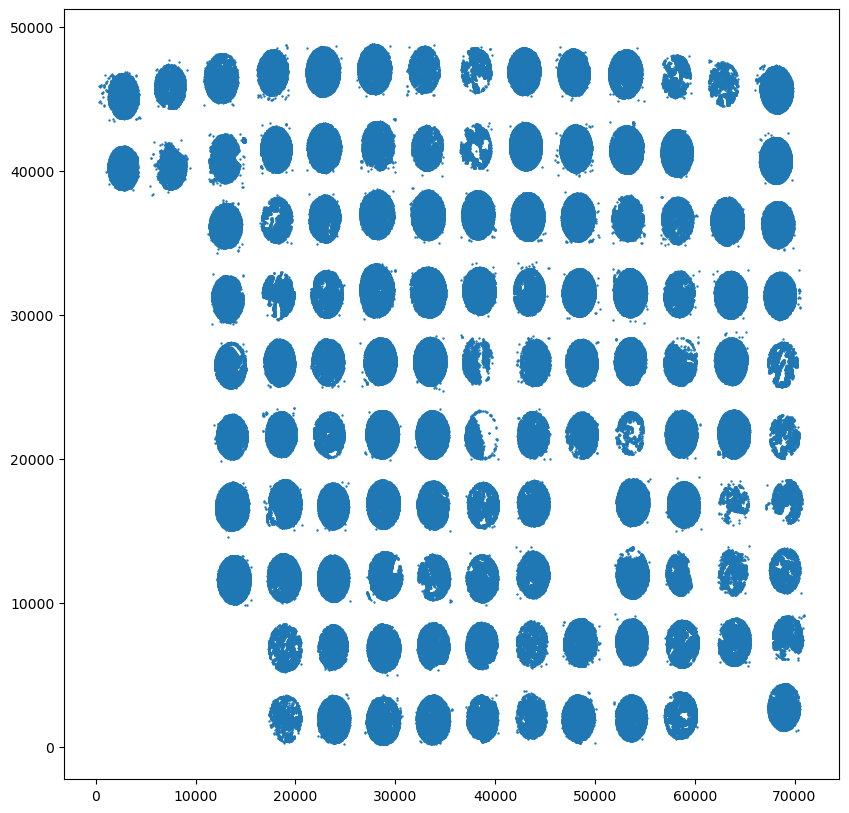

In [ ]:
_,ax = plt.subplots(figsize=(10,10))
ax.scatter(adata.obs['col_spatial_global'],adata.obs['row_spatial_global'],s=0.5)

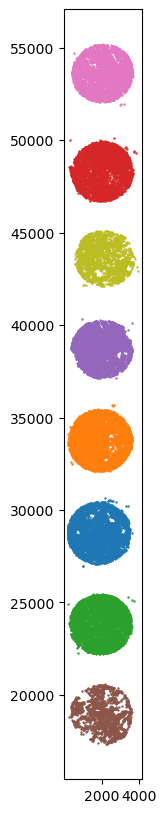

In [ ]:
box_code_num_list = [x+1 for x in range(9)]
_,ax = plt.subplots(figsize=(1,10))

for box_code_num in box_code_num_list:
    ax.scatter(obs['row_spatial_global'][obs['box_code']==box_code_num],obs['col_spatial_global'][obs['box_code']==box_code_num],s=0.5)

### compile vars

In [ ]:
# vars
#   nothing really I have to put here right now
#   i'll just use a placeholder

# determine which markers are not in this dataset, by checking which columns of X are all NaN
#   note we are using X here, not X_2 (X_2 is basically X, except all entirely NaN columns have been removed)
X_nan = np.isnan(X)
X_nan_column_indices = np.where(np.all(X_nan,axis = 0))
X_nan_column_indices = X_nan_column_indices[0]
marker_to_col_dictionary_reverse = {v:k for k,v in marker_to_col_dictionary.items()}
markers_not_in_dataset = [marker_to_col_dictionary_reverse[x] for x in X_nan_column_indices]
markers_in_dataset = [ item for item in master_marker_list if item not in markers_not_in_dataset]

if len(X_nan_column_indices) == 0:
    print('great, there are no "all nan" columns'); print('  ')
else:
    print(f"UH OH, these markers have no fluorescent images in this dataset")
    print(f"   {[marker_to_col_dictionary_reverse[x] for x in X_nan_column_indices]}"); print('  ')

placeholder_list = [0]*len(markers_in_dataset)
var = pd.DataFrame({'placeholder':placeholder_list})
var.index = markers_in_dataset

del X_nan, X_nan_column_indices,markers_not_in_dataset,markers_in_dataset
del placeholder_list, marker_to_col_dictionary_reverse


UH OH, these markers have no fluorescent images in this dataset
   ['CD11C', 'CD11c', 'CD4', 'PD-1', 'Vimentin']
  


### compile X,obs,vars into AnnData object

In [ ]:
adata = sc.AnnData(X=X_2,obs=obs,var=var)

/data1/peerd/parkj16/celldive/myenvironments/celldive00/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
adata

AnnData object with n_obs × n_vars = 612617 × 38
    obs: 'slide_id', 'box_code', 'n', 'row_spatial', 'col_spatial', 'row_spatial_global', 'col_spatial_global'
    var: 'placeholder'

### try save with anndata built in

In [ ]:
# try saving using anndata object built in save method
# adata.write('07_beta_adata.h5ad', compression='lzf')

In [ ]:
# adata = sc.read('07_beta_adata.h5ad')

## display cell positions

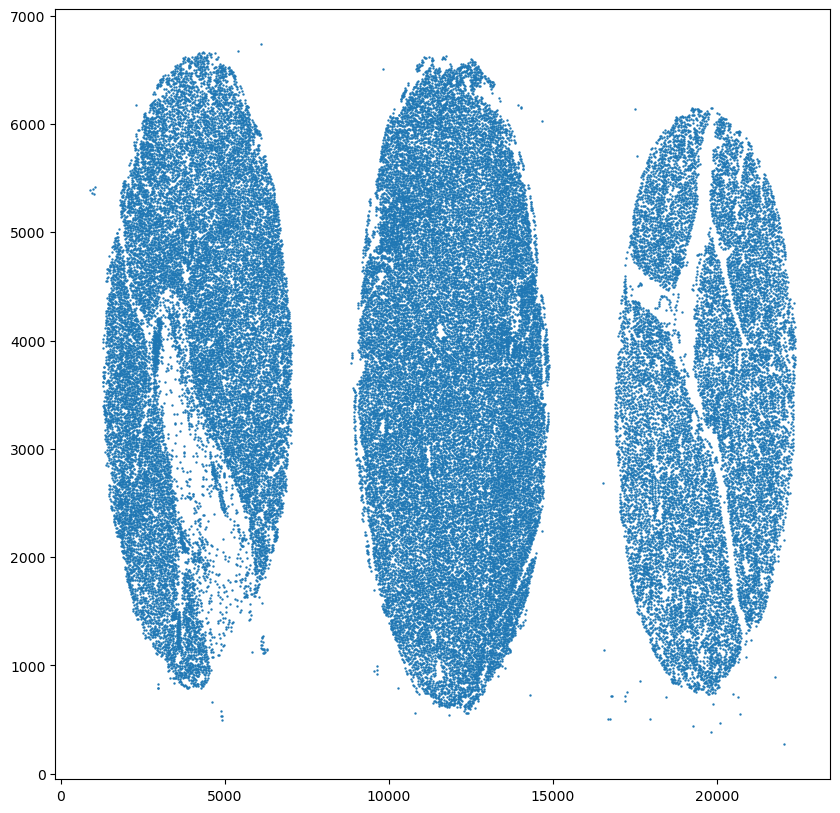

In [ ]:
_,ax = plt.subplots(figsize=(10,10))
ax.scatter(adata.obs['centroid_col_global'],adata.obs['centroid_row_global'],s=0.5)

del ax